# Ramsey-Cass-Koopmans Model (Discrete Time)

**Final Project Starter**

The Ramsey (1928), Cass (1965), and Koopmans (1965) model with CRRA utility and partial depreciation. Unlike Brock-Mirman, there is no analytical solution; the transition dynamics require solving a saddle-path problem numerically via shooting.

All variables are in per-efficiency-unit terms: $k_t = K_t / (A_t L_t)$, $c_t = C_t / (A_t L_t)$, where $K_t$ is capital, $A_t$ is labor-augmenting productivity growing at rate $g$, and $L_t$ is population growing at rate $n$.

The planner maximizes CRRA utility with coefficient of relative risk aversion $\rho$ and discount factor $\beta$, over per-capita consumption $C_t/L_t = A_t c_t$. Capital depreciates at rate $\delta$:

$$\max \sum_{t=0}^{\infty} \beta^t \frac{(A_t c_t)^{1-\rho}}{1-\rho}.$$

Since $A_t = A_0 (1+g)^t$, the effective discount factor on $c_t^{1-\rho}$ is $\beta(1+g)^{1-\rho}$ per period.

The Euler equation in per-efficiency-unit terms is

$$\frac{c_{t+1}}{c_t} = \frac{\left(\beta(f'(k_{t+1}) + 1 - \delta)\right)^{1/\rho}}{(1+g)(1+n)^{1/\rho}}.$$

The $(1+g)$ in the denominator converts from per-capita to per-efficiency-unit growth. The $(1+n)^{1/\rho}$ arises because the resource constraint divides by $(1+g)(1+n)$, which raises the shadow price of capital and slows consumption growth.

The resource constraint in exact discrete time is

$$k_{t+1} = \frac{f(k_t) + (1-\delta)k_t - c_t}{(1+g)(1+n)}.$$

At steady state, $f'(k^*) + 1 - \delta = (1+g)^\rho (1+n)/\beta$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## Calibration and Steady State

In [2]:
# Parameters
alpha = 0.33    # capital share
beta = 0.96     # discount factor (on per-capita utility)
rho = 2.0       # CRRA coefficient
delta = 0.10    # depreciation
n = 0.01        # population growth
g = 0.02        # productivity growth

def f(k):
    return k ** alpha

def f_prime(k):
    return alpha * k ** (alpha - 1)

# Steady state: f'(k*) + 1 - delta = (1+g)^rho * (1+n) / beta
R_ss = (1 + g) ** rho * (1 + n) / beta
mpk_ss = R_ss - 1 + delta
k_ss = (alpha / mpk_ss) ** (1 / (1 - alpha))

# From resource constraint at SS: k = (f(k) + (1-delta)*k - c) / ((1+g)*(1+n))
# => c_ss = f(k_ss) + (1-delta)*k_ss - (1+g)*(1+n)*k_ss
c_ss = f(k_ss) + (1 - delta) * k_ss - (1 + g) * (1 + n) * k_ss
y_ss = f(k_ss)

# Golden rule: f'(k_gr) = (1+g)*(1+n) - 1 + delta
mpk_gr = (1 + g) * (1 + n) - 1 + delta
k_gr = (alpha / mpk_gr) ** (1 / (1 - alpha))
c_gr = f(k_gr) + (1 - delta) * k_gr - (1 + g) * (1 + n) * k_gr

print(f"Steady state: k* = {k_ss:.4f}, c* = {c_ss:.4f}, y* = {y_ss:.4f}")
print(f"Golden rule:  k_gr = {k_gr:.4f}, c_gr = {c_gr:.4f}")
print(f"Dynamic efficiency: k* < k_gr is {k_ss < k_gr}")

Steady state: k* = 2.1998, c* = 1.0107, y* = 1.2971
Golden rule:  k_gr = 4.0072, c_gr = 1.0593
Dynamic efficiency: k* < k_gr is True


## Phase Diagram

- $\Delta k = 0$: $c = f(k) + (1-\delta)k - (1+g)(1+n)k$
- $\Delta c = 0$: vertical line at $k^*$

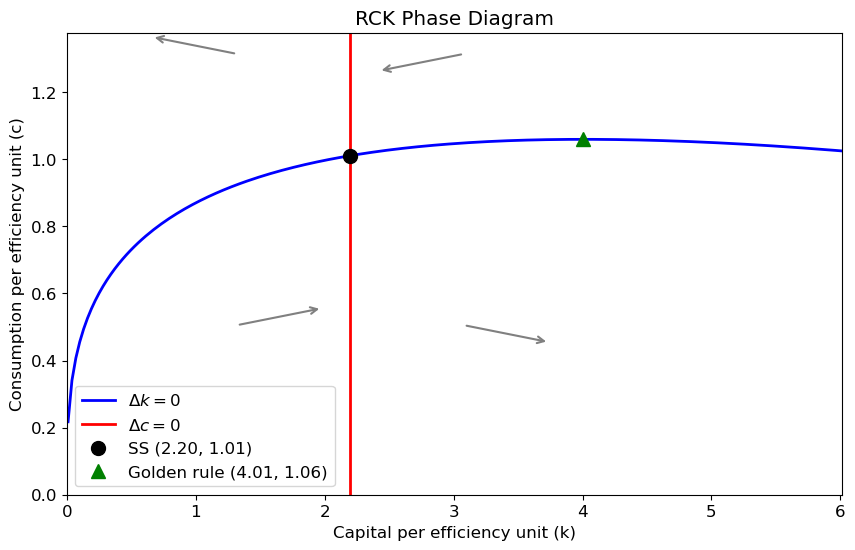

In [3]:
k_grid = np.linspace(0.01, k_gr * 1.5, 200)

# dk = 0 locus
c_dk_zero = f(k_grid) + (1 - delta) * k_grid - (1 + g) * (1 + n) * k_grid

fig, ax = plt.subplots()
ax.plot(k_grid, c_dk_zero, "b-", linewidth=2, label=r"$\Delta k = 0$")
ax.axvline(k_ss, color="r", linewidth=2, label=r"$\Delta c = 0$")
ax.plot(k_ss, c_ss, "ko", markersize=10, zorder=5, label=f"SS ({k_ss:.2f}, {c_ss:.2f})")
ax.plot(k_gr, c_gr, "g^", markersize=10, label=f"Golden rule ({k_gr:.2f}, {c_gr:.2f})")

# Direction arrows
for k_val, c_val in [(k_ss * 0.6, c_ss * 0.5), (k_ss * 1.4, c_ss * 0.5),
                      (k_ss * 0.6, c_ss * 1.3), (k_ss * 1.4, c_ss * 1.3)]:
    dk = (f(k_val) + (1 - delta) * k_val - c_val) / ((1 + g) * (1 + n)) - k_val
    R_val = f_prime(k_val) + 1 - delta
    dc = c_val * ((beta * R_val) ** (1 / rho) / ((1 + g) * (1 + n) ** (1 / rho)) - 1)
    scale_k = 0.3 * k_ss
    scale_c = 0.05 * c_ss
    ax.annotate("", xy=(k_val + scale_k * np.sign(dk), c_val + scale_c * np.sign(dc)),
                xytext=(k_val, c_val),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))

ax.set_xlabel("Capital per efficiency unit (k)")
ax.set_ylabel("Consumption per efficiency unit (c)")
ax.set_title("RCK Phase Diagram")
ax.legend()
ax.set_xlim(0, k_gr * 1.5)
ax.set_ylim(0, c_gr * 1.3)
plt.show()

## Transition Dynamics (Shooting Method)

In [4]:
def simulate_rck(c0, k0, T):
    """Forward-simulate the RCK model from (k0, c0)."""
    k = np.zeros(T)
    c = np.zeros(T)
    k[0] = k0
    c[0] = c0

    for t in range(T - 1):
        k[t+1] = (f(k[t]) + (1 - delta) * k[t] - c[t]) / ((1 + g) * (1 + n))
        R = f_prime(k[t+1]) + 1 - delta
        c[t+1] = c[t] * (beta * R) ** (1 / rho) / ((1 + g) * (1 + n) ** (1 / rho))
        if k[t+1] <= 0 or c[t+1] <= 0:
            return None
    return k, c

T_sim = 80
k0 = 0.5 * k_ss

# Bisect on initial consumption to find the saddle path
c_lo, c_hi = 0.01, f(k0) + (1 - delta) * k0
for _ in range(60):
    c_mid = (c_lo + c_hi) / 2
    result = simulate_rck(c_mid, k0, T_sim)
    if result is None or result[0][-1] < k_ss:
        c_hi = c_mid  # consuming too much
    else:
        c_lo = c_mid

k_path, c_path = simulate_rck((c_lo + c_hi) / 2, k0, T_sim)
y_path = f(k_path)

C:\Users\msant\AppData\Local\Temp\ipykernel_12784\21173744.py:13: RuntimeWarning: invalid value encountered in scalar power
  return alpha * k ** (alpha - 1)


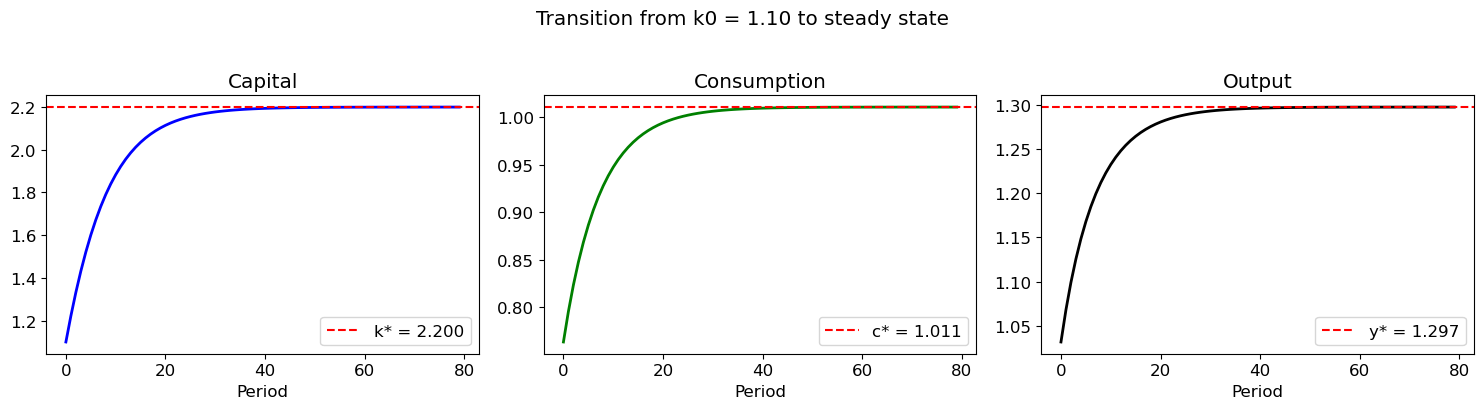

Consumption jumps to c0 = 0.7634 (SS is 1.0107)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_path, "b-", linewidth=2)
axes[0].axhline(k_ss, color="r", linestyle="--", label=f"k* = {k_ss:.3f}")
axes[0].set_title("Capital")
axes[0].set_xlabel("Period")
axes[0].legend()

axes[1].plot(c_path, "g-", linewidth=2)
axes[1].axhline(c_ss, color="r", linestyle="--", label=f"c* = {c_ss:.3f}")
axes[1].set_title("Consumption")
axes[1].set_xlabel("Period")
axes[1].legend()

axes[2].plot(y_path, "k-", linewidth=2)
axes[2].axhline(y_ss, color="r", linestyle="--", label=f"y* = {y_ss:.3f}")
axes[2].set_title("Output")
axes[2].set_xlabel("Period")
axes[2].legend()

plt.suptitle(f"Transition from k0 = {k0:.2f} to steady state", y=1.02)
plt.tight_layout()
plt.show()

print(f"Consumption jumps to c0 = {c_path[0]:.4f} (SS is {c_ss:.4f})")

## Your Project

In groups of three, pick one extension from the list below (or propose your own) and develop it within this notebook. This notebook is your paper and your deliverable. There is no separate report to write: the markdown cells are the written analysis, and the code cells are the implementation.

Your notebook should run from top to bottom without errors. A project that works, produces a clear result, and explains it well will score higher than an ambitious project that does not run.

**Notebook structure** (use markdown cells for the written parts):

1. **Introduction**: State the research question, explain why it matters, and summarize your approach and main findings.
2. **Literature review**: Which models and results from the course does your extension build on? What has been done before? Discuss 3-5 specific papers or course chapters.
3. **Model**: Present the modified equations. Define all new notation. Explain what changed relative to the baseline above and why your assumptions are needed.
4. **Methodology**: Describe calibration choices and any changes to the solution method. Justify parameter values.
5. **Results**: Figures, tables, and statistics that answer your question. Compare the baseline to your extension with specific numbers. Include sensitivity analysis or robustness checks.
6. **Conclusion**: Summarize the main findings, discuss limitations, and identify concrete directions for future work.

Each group also delivers a 10-minute in-class presentation with 5 minutes for questions.

**Due:** May 5, 2026. Submit the notebook (.ipynb) to Canvas. See the full project description and rubric for grading details (Code and Correctness 25, Written Analysis 25, Presentation 20, Creativity and Depth 20, Notebook Quality 10).

## Extension Ideas

The shooting method above works for any deterministic extension. For stochastic extensions, you can adapt the Blanchard-Kahn solver from the RBC notebook by log-linearizing the RCK Euler equation around the steady state.

- **Interest rate dynamics along the transition**: compute the SDF $M_{t+1} = \beta(c_{t+1}/c_t)^{-\rho} / (1+g)^\rho$ at each period from the shooting output. The interest rate starts high (capital is scarce) and falls toward the steady-state value $R^* = (1+g)^\rho(1+n)/\beta$. Compare to the C-CAPM pricing kernel from the asset pricing chapter.
- **Adjustment costs and $q$-theory**: add $\Phi(I/K) \cdot K$ to the resource constraint, following the q-Ramsey model from the growth chapter. The phase diagram gains a second dynamic variable $q$, and the saddle path determines the initial jump in $q$ after a policy shock (as in your assignment).
- **Tax policy**: introduce a corporate income tax $\tau$ and investment tax credit. The steady-state capital stock depends on the Hall-Jorgenson user cost of capital from the investment chapter; a permanent ITC shifts the $\Delta q = 0$ locus.
- **Government spending**: add $G_t$ financed by lump-sum taxes, following the RCK-with-government model from the growth chapter. The shooting method still applies; trace out the transition when $G$ jumps permanently.
- **Decentralization**: solve the competitive equilibrium and verify it matches the planner's solution, as in the Decentralizing RCK chapter. Then introduce a learning-by-doing externality (Romer, 1986) and show where the planner's and market solutions diverge.
- **Stochastic RCK**: add productivity shocks $a_t$ to the production function. The shooting method no longer works because the future is uncertain. Log-linearize the Euler and resource constraints around the steady state and apply the Blanchard-Kahn eigenvalue decomposition from the RBC notebook. This bridges the two starter notebooks. Note: the log-linearization and Blanchard-Kahn method used in the RBC notebook go beyond the lecture notes; you will need to study that notebook's solver before adapting it here.